<a href="https://colab.research.google.com/github/varnika1237/aiml_training_program/blob/main/Varnika_AIML_Module_1_Lab_2_Machine_Learning_terms_and_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [2]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [3]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [4]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

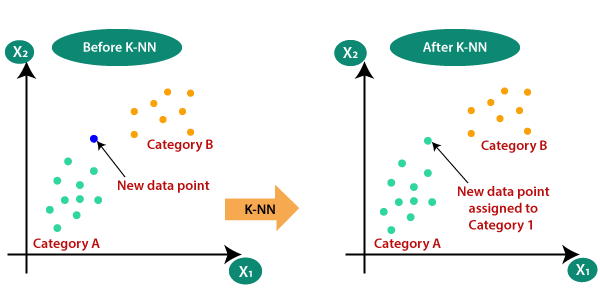

In [5]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [6]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [7]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [8]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [9]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [10]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [11]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


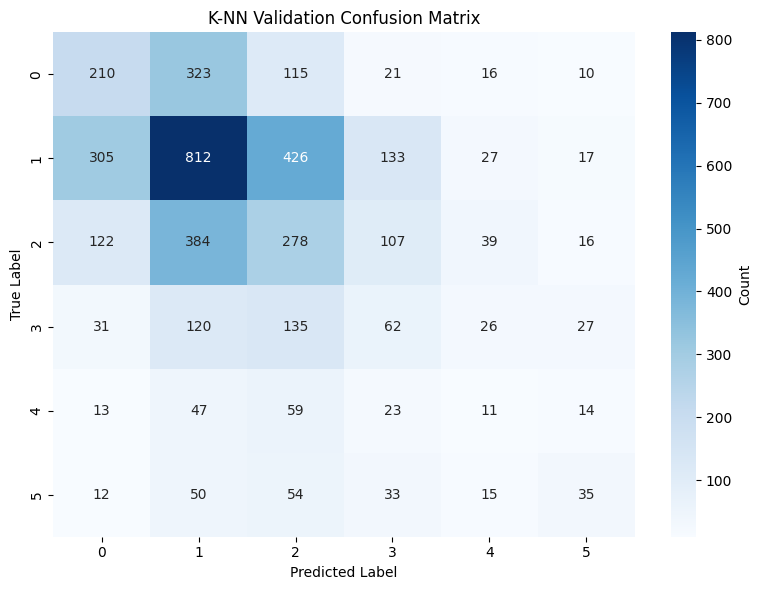

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [13]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [14]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [15]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [16]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

In [17]:
# Experiment: Effect of training/validation split
# We keep the 20% test set fixed, as done earlier in the notebook.

validation_percentages = [0.1, 1, 5, 10, 20, 25, 30, 40, 50, 60, 70, 80, 90, 95, 99, 99.9]

nn_validation_accuracy = []
random_validation_accuracy = []

# Test accuracy of NN using the complete training data
testpred = NN(alltraindata, alltrainlabel, testdata)
test_accuracy = Accuracy(testlabel, testpred)

for val_percent in validation_percentages:

    # splitpercent represents TRAINING percentage in the split() function
    train_percent = 1 - val_percent / 100

    # Avoid extremely small training/validation sets causing empty sets
    traindata, trainlabel, valdata, vallabel = split(
        alltraindata,
        alltrainlabel,
        train_percent
    )

    # Nearest Neighbour
    valpred_nn = NN(traindata, trainlabel, valdata)
    nn_acc = Accuracy(vallabel, valpred_nn)

    # Random Classifier
    valpred_random = RandomClassifier(traindata, trainlabel, valdata)
    random_acc = Accuracy(vallabel, valpred_random)

    nn_validation_accuracy.append(nn_acc * 100)
    random_validation_accuracy.append(random_acc * 100)

# Print results
print("Validation % | Training % | NN Accuracy | Random Accuracy")

for i in range(len(validation_percentages)):
    print(
        f"{validation_percentages[i]:10.1f}% | "
        f"{100-validation_percentages[i]:10.1f}% | "
        f"{nn_validation_accuracy[i]:11.2f}% | "
        f"{random_validation_accuracy[i]:15.2f}%"
    )

print("\nNN Test Accuracy:", test_accuracy * 100, "%")

Validation % | Training % | NN Accuracy | Random Accuracy
       0.1% |       99.9% |       33.33% |           11.11%
       1.0% |       99.0% |       33.75% |           16.25%
       5.0% |       95.0% |       33.65% |           16.71%
      10.0% |       90.0% |       33.25% |           16.54%
      20.0% |       80.0% |       34.17% |           17.03%
      25.0% |       75.0% |       34.89% |           17.36%
      30.0% |       70.0% |       34.05% |           16.18%
      40.0% |       60.0% |       33.59% |           16.89%
      50.0% |       50.0% |       33.02% |           16.88%
      60.0% |       40.0% |       32.26% |           17.17%
      70.0% |       30.0% |       31.31% |           16.38%
      80.0% |       20.0% |       30.84% |           16.80%
      90.0% |       10.0% |       29.92% |           16.93%
      95.0% |        5.0% |       28.93% |           16.21%
      99.0% |        1.0% |       25.82% |           17.38%
      99.9% |        0.1% |       33.20% |

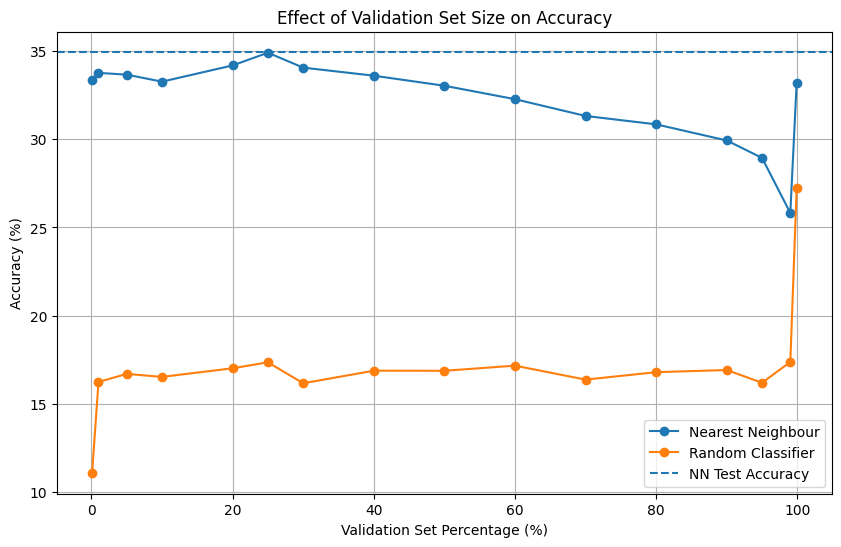

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    validation_percentages,
    nn_validation_accuracy,
    marker='o',
    label='Nearest Neighbour'
)

plt.plot(
    validation_percentages,
    random_validation_accuracy,
    marker='o',
    label='Random Classifier'
)

plt.axhline(
    test_accuracy * 100,
    linestyle='--',
    label='NN Test Accuracy'
)

plt.xlabel("Validation Set Percentage (%)")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Validation Set Size on Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Answers

### 1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?

For the **Nearest Neighbour classifier**, increasing the validation set percentage means that the training set becomes smaller. Since Nearest Neighbour depends on the training samples to find the closest example, reducing the training set generally reduces its validation accuracy.

When we reduce the validation percentage, more data is available for training. Therefore, the Nearest Neighbour classifier generally gets better validation accuracy. However, if the validation set becomes very small, the measured validation accuracy becomes less reliable because it depends on only a few samples.

For the **Random Classifier**, changing the training/validation split has much less effect on the expected accuracy. The classifier randomly assigns one of the available class labels, so its accuracy is expected to remain around 1/(number of classes), which is approximately 16.67% for 6 classes. The actual value changes slightly because the predictions are random.

Therefore:

- Increasing validation percentage → smaller training set.
- Decreasing validation percentage → larger training set.
- Very small validation set → validation accuracy becomes unstable.
- Very large validation set → less data is available for training.
- Random classifier is much less affected by training-set size.

---

### 2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?

There is a trade-off between the training set size and the validation set size.

If the training set is very large and the validation set is very small, the model has enough data for training, but the validation accuracy may not be a reliable estimate of the test accuracy because it is calculated using very few samples.

If the validation set is very large and the training set is very small, the validation accuracy is measured using many samples, but the model has fewer samples to learn from. This is particularly important for the Nearest Neighbour classifier.

In the notebook, with the 75% training and 25% validation split, the Nearest Neighbour validation accuracy was about 34.11%, while the test accuracy was about 34.92%. These values are reasonably close.

The notebook also shows that changing the random split causes the validation accuracy to change. This happens because different samples are included in the validation set each time.

For the Random Classifier, the validation accuracy stays close to its expected random accuracy, so the size of the training set has much less influence on its performance.

Thus, the validation set should be large enough to give a reliable estimate, but not so large that the training set becomes too small.

---

### 3. What is a good percentage to reserve for the validation set so that these two factors are balanced?

A reasonable choice is around **20%–25% for validation** and **75%–80% for training**.

In this notebook, **25% validation and 75% training** is a good choice because it provides:

- Enough training data for the Nearest Neighbour classifier.
- Enough validation samples to obtain a reasonably stable estimate.
- A validation accuracy that is reasonably close to the test accuracy.

For example, in the original experiment:

- Training set = 75%
- Validation set = 25%
- Nearest Neighbour validation accuracy ≈ 34.11%
- Nearest Neighbour test accuracy ≈ 34.92%

Therefore, **75% training and 25% validation** provides a good balance for this experiment.

---

### Extreme cases

When the validation set is extremely small, such as **0.1%**, almost all data is used for training. Although the model has many training samples, the validation accuracy is based on very few samples and can therefore be highly unstable.

When the validation set is extremely large, such as **99.9%**, almost all the data is used for validation and only 0.1% is available for training. The Nearest Neighbour classifier then has very little training data, so its accuracy can become very poor.

Therefore, neither extreme is useful.

A moderate split such as **75% training and 25% validation** gives a better balance.

> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1-Nearest Neighbour
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)

# Predict on test dataset
pred1 = knn1.predict(testdata)

# Calculate accuracy
accuracy1 = accuracy_score(testlabel, pred1)

print("1-Nearest Neighbour Accuracy:", accuracy1 * 100, "%")


# 3-Nearest Neighbour
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)

# Predict on test dataset
pred3 = knn3.predict(testdata)

# Calculate accuracy
accuracy3 = accuracy_score(testlabel, pred3)

print("3-Nearest Neighbour Accuracy:", accuracy3 * 100, "%")

1-Nearest Neighbour Accuracy: 34.91795366795367 %
3-Nearest Neighbour Accuracy: 36.05212355212355 %


### Exercise: Comparing 1-Nearest Neighbour and 3-Nearest Neighbour

I implemented both 1-Nearest Neighbour and 3-Nearest Neighbour classifiers using the `KNeighborsClassifier` from the scikit-learn library. Both classifiers were trained using the same training dataset and tested on the same test dataset.

The results were:

| Classifier                | Test Accuracy |
| ------------------------- | ------------: |
| 1-Nearest Neighbour (K=1) |        34.92% |
| 3-Nearest Neighbour (K=3) |        36.05% |

The 1-nearest neighbour classifier makes its prediction based on the single closest training point. The 3-nearest neighbour classifier considers the three closest training points and predicts the class based on majority voting.

In this experiment, the **3-nearest neighbour classifier achieved a higher test accuracy (36.05%) than the 1-nearest neighbour classifier (34.92%)**.

Therefore, for this particular dataset and test set, using 3 neighbours gave a slightly better accuracy than using only 1 neighbour.


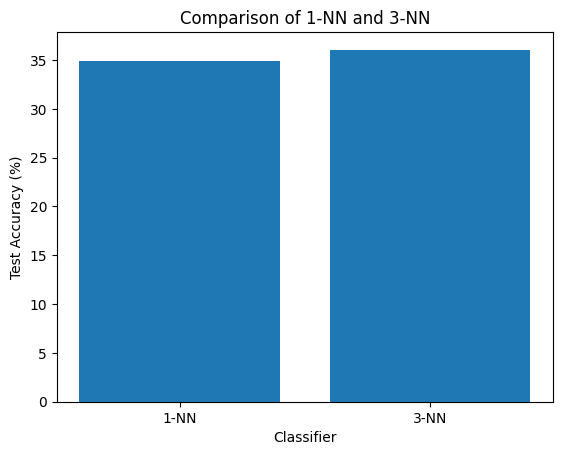

In [20]:
import matplotlib.pyplot as plt

models = ["1-NN", "3-NN"]
accuracies = [accuracy1 * 100, accuracy3 * 100]

plt.bar(models, accuracies)

plt.xlabel("Classifier")
plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of 1-NN and 3-NN")

plt.show()

## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [22]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [23]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 34.227148610913666 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


###Answers:

### 1. Does averaging the validation accuracy across multiple splits give more consistent results?

Yes. Averaging the validation accuracy over multiple random train-validation splits gives more consistent results.

A single split can give a slightly higher or lower accuracy depending on which samples are randomly selected for the training and validation sets. When we repeat the split several times and take the average, these random variations are reduced.

Therefore, the average validation accuracy is generally more stable than the accuracy obtained from only one random split.

---

### 2. Does it give a more accurate estimate of test accuracy?

Yes, generally it gives a better estimate of the test accuracy than using only one validation split.

Since different random splits are used, the average validation accuracy represents the model's performance across several different training and validation sets. This makes it less dependent on one particular random split.

If the validation accuracy is close to the test accuracy, it indicates that the validation process is providing a reasonable estimate of how the model performs on unseen data.

---

### 3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?

Increasing the number of iterations generally makes the average validation accuracy more stable.

With a small number of iterations, the result can still be affected by random variations in the train-validation splits. As the number of iterations increases, more random splits are considered, so the average becomes more reliable and tends to fluctuate less.

However, after a certain point, increasing the number of iterations gives only a small improvement in the estimate while increasing the computation time.

Therefore, a higher number of iterations generally gives a more stable estimate, but there are diminishing benefits after enough iterations.

---

### 4. Can we deal with a very small train dataset or validation dataset by increasing the iterations?

No. Increasing the number of iterations cannot completely solve the problem of having a very small training or validation dataset.

If the training dataset is very small, the model does not have enough examples to learn from. Repeating the experiment many times does not change the fact that each individual model is trained on very little data.

Similarly, if the validation dataset is extremely small, its accuracy can vary greatly because it contains too few samples. Increasing the number of iterations can make the average more stable, but it does not provide more independent validation samples within each split.

Therefore, it is important to choose a reasonable balance between the training and validation set sizes. Increasing the number of iterations helps reduce the effect of random splitting, but it cannot replace having sufficiently large training and validation datasets.


> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

Exercise: Effect of Number of Splits and Split Size

The accuracy of the 1-nearest neighbour and 3-nearest neighbour classifiers is compared by changing the number of random train-validation splits and the training-validation split size.

In [26]:
from sklearn.neighbors import KNeighborsClassifier

# 3-NN classifier
def NN3(traindata, trainlabel, testdata):
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(traindata, trainlabel)
    return model.predict(testdata)

Effect of Number of Splits

The number of random train-validation splits is varied while keeping the training set at 75% and the validation set at 25%. The average validation accuracy of 1-NN and 3-NN is calculated for each number of splits.

In [27]:
# Compare 1-NN and 3-NN for different numbers of splits

iterations_list = [1, 5, 10, 20, 50]

nn1_accuracies = []
nn3_accuracies = []

for iterations in iterations_list:

    # 1-NN
    acc1 = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        75 / 100,
        iterations,
        classifier=NN
    )

    # 3-NN
    acc3 = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        75 / 100,
        iterations,
        classifier=NN3
    )

    nn1_accuracies.append(acc1 * 100)
    nn3_accuracies.append(acc3 * 100)

    print("Number of splits:", iterations)
    print("1-NN Accuracy:", acc1 * 100, "%")
    print("3-NN Accuracy:", acc3 * 100, "%")
    print()

Number of splits: 1
1-NN Accuracy: 33.16264325774201 %
3-NN Accuracy: 34.81624758220503 %

Number of splits: 5
1-NN Accuracy: 33.8933941486125 %
3-NN Accuracy: 34.15612652583045 %

Number of splits: 10
1-NN Accuracy: 34.0770696743916 %
3-NN Accuracy: 34.49994493599809 %

Number of splits: 20
1-NN Accuracy: 34.245752667390036 %
3-NN Accuracy: 34.669939351145516 %

Number of splits: 50
1-NN Accuracy: 34.08071112733041 %
3-NN Accuracy: 34.65944996368829 %



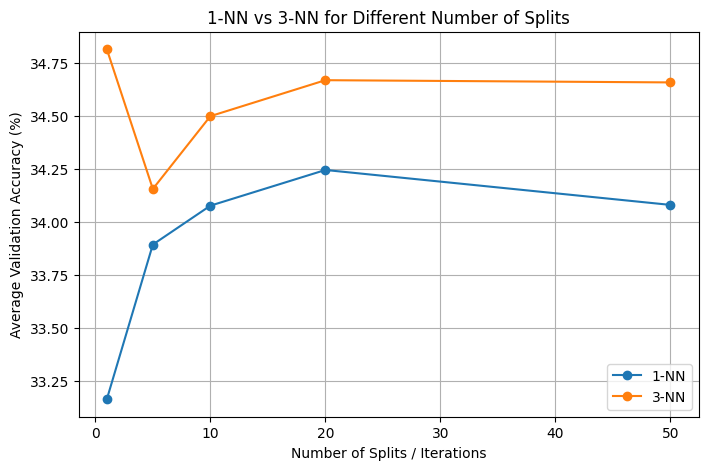

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(iterations_list, nn1_accuracies,
         marker='o', label='1-NN')

plt.plot(iterations_list, nn3_accuracies,
         marker='o', label='3-NN')

plt.xlabel("Number of Splits / Iterations")
plt.ylabel("Average Validation Accuracy (%)")
plt.title("1-NN vs 3-NN for Different Number of Splits")
plt.legend()
plt.grid(True)

plt.show()

Effect of Split Size

The training-validation split size is varied while keeping the number of random splits fixed at 10. The training set percentages are 50%, 60%, 70%, 75%, 80% and 90%. The remaining data is used as the validation set.

In [29]:
# Compare 1-NN and 3-NN for different split sizes

split_sizes = [50, 60, 70, 75, 80, 90]

nn1_split_accuracies = []
nn3_split_accuracies = []

for train_percent in split_sizes:

    # 1-NN
    acc1 = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        train_percent / 100,
        10,
        classifier=NN
    )

    # 3-NN
    acc3 = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        train_percent / 100,
        10,
        classifier=NN3
    )

    nn1_split_accuracies.append(acc1 * 100)
    nn3_split_accuracies.append(acc3 * 100)

    print("Training:", train_percent, "%")
    print("Validation:", 100 - train_percent, "%")
    print("1-NN Accuracy:", acc1 * 100, "%")
    print("3-NN Accuracy:", acc3 * 100, "%")
    print()

Training: 50 %
Validation: 50 %
1-NN Accuracy: 32.782572818261265 %
3-NN Accuracy: 33.34077583273223 %

Training: 60 %
Validation: 40 %
1-NN Accuracy: 33.531885035076826 %
3-NN Accuracy: 34.06853815445712 %

Training: 70 %
Validation: 30 %
1-NN Accuracy: 33.73120815360576 %
3-NN Accuracy: 34.45626279391419 %

Training: 75 %
Validation: 25 %
1-NN Accuracy: 34.308830195241434 %
3-NN Accuracy: 34.78555379269295 %

Training: 80 %
Validation: 20 %
1-NN Accuracy: 34.1109883094726 %
3-NN Accuracy: 35.07559485176744 %

Training: 90 %
Validation: 10 %
1-NN Accuracy: 34.47773185314011 %
3-NN Accuracy: 35.571122133904574 %



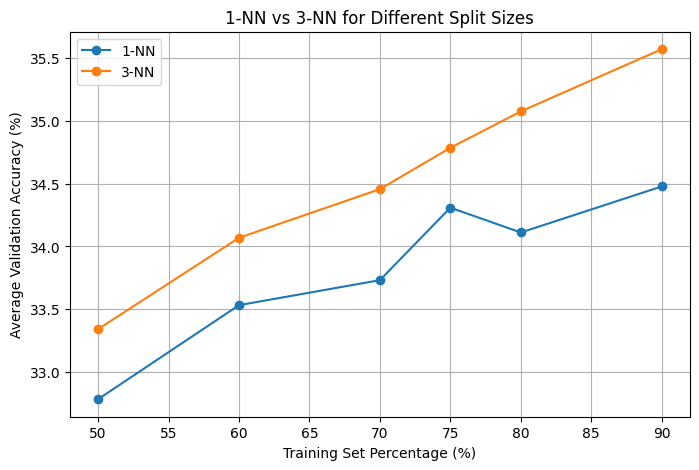

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(split_sizes, nn1_split_accuracies,
         marker='o', label='1-NN')

plt.plot(split_sizes, nn3_split_accuracies,
         marker='o', label='3-NN')

plt.xlabel("Training Set Percentage (%)")
plt.ylabel("Average Validation Accuracy (%)")
plt.title("1-NN vs 3-NN for Different Split Sizes")
plt.legend()
plt.grid(True)

plt.show()

Conclusion

Increasing the number of random train-validation splits generally makes the average validation accuracy more stable because the accuracy is averaged over multiple splits. After a sufficient number of splits, further increasing the number of splits has a smaller effect on the average accuracy.

The split size also affects the results. A larger training set provides the KNN classifier with more examples from which to find neighbours. However, if the validation set becomes very small, the validation accuracy may be less reliable because it is calculated using fewer samples.

The 1-NN classifier makes its prediction using the single nearest neighbour, whereas 3-NN uses the three nearest neighbours and majority voting. Therefore, their validation accuracies can differ depending on the number of splits and the training-validation split size.